# 项目练习：车道线检测

在自动驾驶中，让汽车保持在车道线内是非常重要的。车道线检测是自动驾驶和智能交通系统中的一个基础任务，用于识别车辆当前行驶的车道。本次项目使用传统计算机视觉方法（基于 OpenCV）实现简单的车道线检测。主要用到的是库有：openCV,numpy, matplotlib。主要包括下面这么几个步骤：
- 1. 图像加载；
- 2. 图像预处理：图片灰度化，高斯滤波；
- 3. Canny边缘检测；
- 4. 感兴趣区域检测；
- 5. 霍夫直线检测；
- 6. 绘制车道线；
- 7. 图片和视频测试（略）；
- 8. 可视化界面pyqt5（略）

# 0.导入库

In [ ]:
import cv2 as cv              # OpenCV计算机视觉库
import numpy as np            # NumPy数值计算库
import matplotlib.pyplot as plt  # Matplotlib绑图库

In [ ]:
def show(img):
    """自定义显示函数：自动判断灰度图或彩色图并正确显示"""
    if img.ndim == 2:  # 灰度图
        plt.imshow(img, cmap='gray')
    else:  # 彩色图，BGR转RGB
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        plt.imshow(img)
    plt.show()

# 1. 图像加载

In [ ]:
img = cv.imread('pic/0764.jpg')  # 读取车道场景图片
show(img)

# 2. 图像预处理：图片灰度化，高斯滤波

In [ ]:
# 在下划线的区域内"_____"填充代码

# 在下划线的区域内"_____"填充代码

# 图片灰度化：将BGR三通道图像转为单通道灰度图，简化后续处理
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# 高斯滤波：(5,5)为卷积核大小，sigma=0时由核大小自动计算，去除噪声平滑图像
blurred = cv.GaussianBlur(gray, (5, 5), 0)

# 3. 边缘检测

常用的边缘提取算法有Canny算法和Sobel算法.根据实际要处理的图像来选择算法.

In [ ]:
# Canny边缘检测：双阈值50和150，检测图像中的边缘（车道线的轮廓）
edges_canny = cv.Canny(blurred, 50, 150)
show(edges_canny)

# 4. 感兴趣区域检测

边缘提取完成后，需要检测的车道线被凸显出来了。为了实现汽车所在车道的车道线检测，我们需要将感兴趣的区域（Region of Interest）提取出来。提取感兴趣区域最简单的方式就是“截取”。即截取车道的部分，抛弃背景的部分。

In [21]:
def region_of_interest(img, vertices):
    # 定义一个和输入图像同样大小的全黑图像mask，这个mask也称掩膜
    # 掩膜的介绍，可参考：https://www.cnblogs.com/skyfsm/p/6894685.html
    # fillPoly函数可参考：https://blog.csdn.net/m0_63070489/article/details/146923535
    mask = np.zeros_like(img)   

    #根据输入图像的通道数，忽略的像素点是多通道的白色，还是单通道的白色
    if len(img.shape) > 2:
        channel_count = img.shape[2]  # i.e. 3 or 4 depending on your image
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255

    #[vertices]中的点组成了多边形，将在多边形内的mask像素点保留，
    cv.fillPoly(mask, [vertices], ignore_mask_color)

    #与mask做"与"操作，即仅留下多边形部分的图像
    masked_image = cv.bitwise_and(img, mask)

    return masked_image

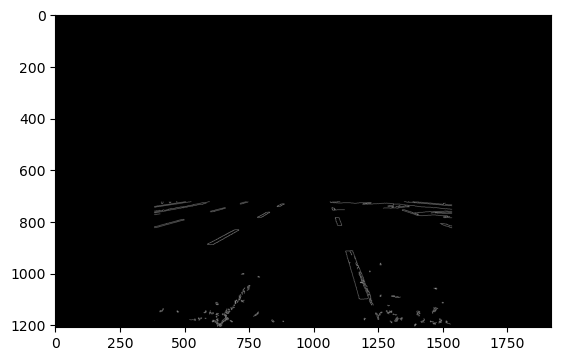

In [43]:
# 3. 截取矩形ROI区域

# 获取图像的尺寸信息
rows, cols = edges_canny.shape[:2]  # 获取图像高度和宽度

# 定义矩形区域的顶点坐标（梯形区域，模拟车道视角）
# 这个梯形区域覆盖了图像下半部分，对应车辆前方的车道区域
vertices = np.array([
    [int(0.2 * cols), int(0.6 * rows)],
    [int(0.8 * cols), int(0.6 * rows)],
    [int(0.8 * cols), rows],
    [int(0.2 * cols), rows]
], dtype=np.int32)

# 调用region_of_interest函数提取ROI区域
roi_image_rectangle = region_of_interest(edges_canny, vertices)

# 显示ROI区域边缘检测结果
show(roi_image_rectangle)

# 5. 霍夫直线检测

In [ ]:
# 形态学膨胀操作：用5x5的全1核膨胀一次，加粗边缘线段使其更连续
kernel = np.ones((5,5), np.uint8)  # 5x5的全1结构元素
roi_dilated = cv.dilate(roi_image_rectangle, kernel, iterations=1)  # 膨胀1次

In [ ]:
# HoughLinesP：概率霍夫直线检测，直接返回线段端点坐标
lines = cv.HoughLinesP(
    roi_image_rectangle,  # ROI区域的边缘图
    rho=1,                # 距离分辨率1像素
    theta=np.pi/180,      # 角度分辨率1度
    threshold=20,         # 最小投票数
    minLineLength=30,     # 最短线段长度30像素
    maxLineGap=50         # 允许的最大断裂间隙50像素
)

# 在黑色背景上绘制检测到的直线，便于可视化
line_image = np.zeros_like(roi_image_rectangle)  # 创建与ROI同尺寸的黑色图像
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(line_image, (x1, y1), (x2, y2), 255, 2)  # 绘制白色直线，线宽2

show(line_image)

# 6. 绘制车道线

In [ ]:
# 将检测到的车道线绘制在原始彩色图像上
lane_image = np.copy(img)  # 复制原图，不修改原始图像

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(lane_image, (x1, y1), (x2, y2), (0, 255, 0), 5)  # 绘制绿色线段，线宽5

show(lane_image)  # 显示叠加了车道线的原始图像